In [1]:
# Run this in a Jupyter notebook cell (Python kernel)
# Requirements: pandas, numpy, scipy, statsmodels
# If missing: pip install pandas numpy scipy statsmodels

import os
import gzip
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

outdir = "./hnsc_counts_outputs"
os.makedirs(outdir, exist_ok=True)

# EDIT this path if file is elsewhere
expr_path = "TCGA-HNSC.star_counts.tsv.gz"

# list of integrin genes you're interested in
integrin_genes = ["ITGAV","ITGB3","ITGB5","ITGB6","ITGB8","ITGA2","ITGB1","ITGA3","ITGA5","ITGA6","ITGB4"]

print("Loading STAR counts from:", expr_path)
# read gz or plain
if expr_path.endswith(".gz"):
    df = pd.read_csv(expr_path, sep="\t", index_col=0, compression="gzip")
else:
    df = pd.read_csv(expr_path, sep="\t", index_col=0)

print("Raw shape (genes x samples):", df.shape)

# Clean gene index: strip Ensembl version if present
df.index = df.index.astype(str).str.replace(r"\.\d+$", "", regex=True)

# Quick check: are column names TCGA barcodes? If not, we'll still try to infer.
cols = df.columns.tolist()

def sample_type_from_barcode(barcode):
    try:
        code = barcode.split("-")[3][:2]
        return "Normal" if code == "11" else "Tumor"
    except Exception:
        return "Unknown"

sample_types = [sample_type_from_barcode(c) for c in cols]
meta = pd.DataFrame({"sample": cols, "sample_type": sample_types}).set_index("sample")
print("Sample type counts (by barcode inference):")
print(meta['sample_type'].value_counts())

# If no normals found, print warning (but continue)
if meta['sample_type'].value_counts().get('Normal', 0) < 1:
    print("Warning: no Normal samples detected by barcode parsing. If your columns are not barcodes, supply sample map.")

# Normalize counts -> CPM then log2(CPM+1)
libsizes = df.sum(axis=0)
cpm = df.divide(libsizes, axis=1) * 1e6
log2cpm = np.log2(cpm + 1)

# Define tumor and normal columns (based on barcode inference)
tumor_cols = meta[meta['sample_type'] == 'Tumor'].index.tolist()
normal_cols = meta[meta['sample_type'] == 'Normal'].index.tolist()
print(f"#tumor = {len(tumor_cols)}, #normal = {len(normal_cols)}")

if len(normal_cols) < 3:
    print("Warning: fewer than 3 normals detected — interpret p-values with caution.")

# DGE: Welch t-test per gene (on log2CPM)
genes = log2cpm.index.tolist()
results = []
for g in genes:
    a = log2cpm.loc[g, tumor_cols].values
    b = log2cpm.loc[g, normal_cols].values
    log2fc = np.nanmean(a) - np.nanmean(b)
    try:
        t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
    except Exception:
        p = np.nan
    results.append((g, log2fc, p))

res = pd.DataFrame(results, columns=["gene","log2FC","pvalue"]).set_index("gene")
res["padj"] = multipletests(res["pvalue"].fillna(1), method="fdr_bh")[1]

# Save full results
res_sorted = res.sort_values("log2FC", ascending=False)
res_sorted.to_csv(os.path.join(outdir, "hnsc_star_counts_dge_all_genes.csv"))
print("Saved all-gene DGE to:", os.path.join(outdir, "hnsc_star_counts_dge_all_genes.csv"))

# Extract integrins (if present)
present = [g for g in integrin_genes if g in res_sorted.index]
integrin_res = res_sorted.loc[present]
integrin_res.to_csv(os.path.join(outdir, "hnsc_star_counts_integrin_dge.csv"))
print("Saved integrin DGE to:", os.path.join(outdir, "hnsc_star_counts_integrin_dge.csv"))
print("Integrins found:", present)
print(integrin_res)

# Quick top hits
print("\nTop 10 upregulated genes (by log2FC):")
print(res_sorted.head(10))

print("\nDone. Outputs in folder:", outdir)


Loading STAR counts from: TCGA-HNSC.star_counts.tsv.gz
Raw shape (genes x samples): (60660, 566)
Sample type counts (by barcode inference):
Tumor     522
Normal     44
Name: sample_type, dtype: int64
#tumor = 522, #normal = 44
Saved all-gene DGE to: ./hnsc_counts_outputs/hnsc_star_counts_dge_all_genes.csv
Saved integrin DGE to: ./hnsc_counts_outputs/hnsc_star_counts_integrin_dge.csv
Integrins found: []
Empty DataFrame
Columns: [log2FC, pvalue, padj]
Index: []

Top 10 upregulated genes (by log2FC):
                   log2FC        pvalue          padj
gene                                                 
ENSG00000234041  3.322617  1.106454e-15  5.390962e-14
ENSG00000128713  3.205709  1.948373e-14  7.518339e-13
ENSG00000251144  3.138142  1.412362e-19  1.364233e-17
ENSG00000123388  3.035256  3.284358e-12  8.165139e-11
ENSG00000139800  3.031356  3.009260e-13  9.299119e-12
ENSG00000260976  3.026761  1.810450e-19  1.724048e-17
ENSG00000181355  3.022169  2.383570e-16  1.307300e-14
ENSG0000023

In [2]:
# If not installed yet:
# !pip install mygene

import mygene

mg = mygene.MyGeneInfo()

print("Mapping Ensembl IDs to gene symbols...")
gene_info = mg.querymany(df.index.tolist(), scopes="ensembl.gene", fields="symbol", species="human")

# Make a mapping dataframe
map_df = pd.DataFrame(gene_info)[["query", "symbol"]].dropna()
id_to_symbol = dict(zip(map_df["query"], map_df["symbol"]))

# Add symbols to results
res_sorted["symbol"] = res_sorted.index.map(id_to_symbol)
res_sorted = res_sorted.dropna(subset=["symbol"])
res_sorted = res_sorted.set_index("symbol", drop=True)

# Re -check for integrins
integrin_res = res_sorted.loc[res_sorted.index.intersection(integrin_genes)]
integrin_res.to_csv(os.path.join(outdir, "hnsc_star_counts_integrin_dge_with_symbols.csv"))

print("✅ Mapped to gene symbols.")
print("Integrins found:", integrin_res.index.tolist())
print(integrin_res)


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Mapping Ensembl IDs to gene symbols...


29 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000188660', 2), ('ENSG00000215156', 2), ('ENSG00000226506', 2), ('E
1303 input query terms found no hit:	['ENSG00000002079', 'ENSG00000002586.20_PAR_Y', 'ENSG00000112096', 'ENSG00000124333.16_PAR_Y', 'ENSG


✅ Mapped to gene symbols.
Integrins found: ['ITGA5', 'ITGA6', 'ITGA3', 'ITGB4', 'ITGAV', 'ITGB6', 'ITGB1', 'ITGB8', 'ITGA2', 'ITGB5', 'ITGB3']
          log2FC        pvalue          padj
symbol                                      
ITGA5   0.240959  2.732922e-16  1.481493e-14
ITGA6   0.136339  1.163196e-11  2.602710e-10
ITGA3   0.116819  1.707829e-07  1.569174e-06
ITGB4   0.086973  2.914673e-07  2.550181e-06
ITGAV   0.063775  9.930026e-06  5.924030e-05
ITGB6   0.060681  1.836402e-02  4.258750e-02
ITGB1   0.021871  1.835320e-01  2.913114e-01
ITGB8   0.020019  3.312710e-01  4.660119e-01
ITGA2   0.018913  3.781479e-01  5.175663e-01
ITGB5   0.018125  1.391858e-01  2.337997e-01
ITGB3  -0.003324  9.397339e-01  1.000000e+00


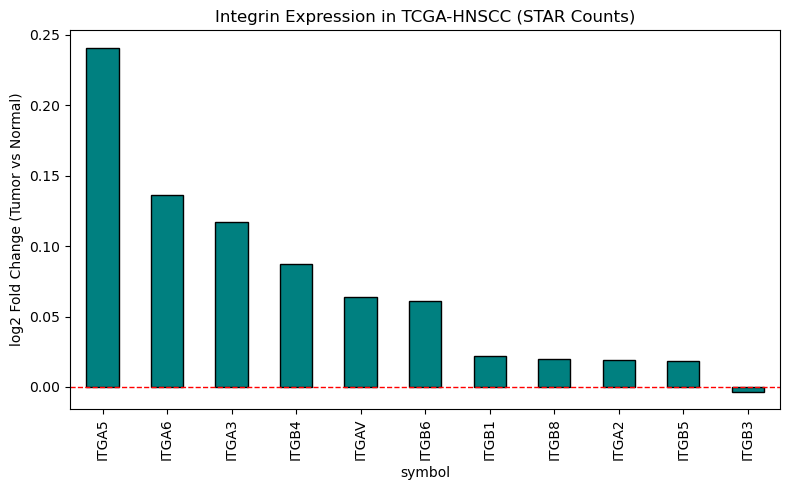

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Bar plot of integrin log2FCs
integrin_res["log2FC"].sort_values(ascending=False).plot(
    kind="bar", color="teal", edgecolor="black"
)

# Add baseline (no change line)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)

# Labels and title
plt.ylabel("log2 Fold Change (Tumor vs Normal)")
plt.title("Integrin Expression in TCGA-HNSCC (STAR Counts)")

# Tidy up layout
plt.tight_layout()
plt.show()
